# 07 · Response prediction with campaign-level temporal validation
**Business question:** using what we knew before a campaign, can we rank customers for a *future* campaign better than simple rules?

**Design.** No campaign dates exist, but campaigns are ordered (C1 → C6). We build a customer × campaign panel:
for campaign *k*, the target is acceptance of *k* and history features use **only campaigns 1…k−1**. Models are trained
on C2–C5 and tested on the later pilot C6 for all 2,019 customers. Hyper-parameters are chosen by leave-one-campaign-out
CV inside C2–C5. Declared model-choice rule: prefer logistic regression unless boosting beats it by > 0.01 LOCO PR-AUC.

**Primary metric:** PR-AUC and lift/profit at a contact budget (positives are 7–15 %, and the business contacts a top slice).
Random Forest was not added: gradient boosting already represents the non-linear family and did not earn its place.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:41:20] response model (temporal validation)
train rows 8076 test rows 2019 | primary: logistic_regression


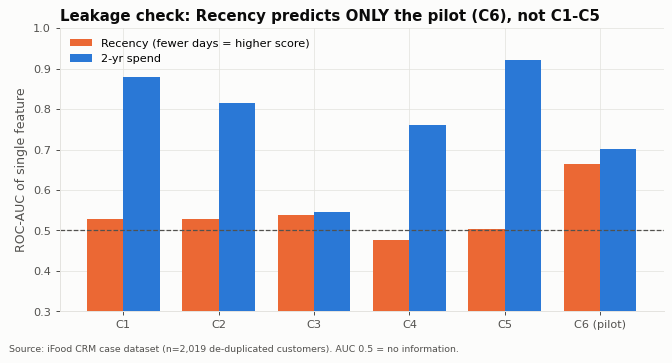

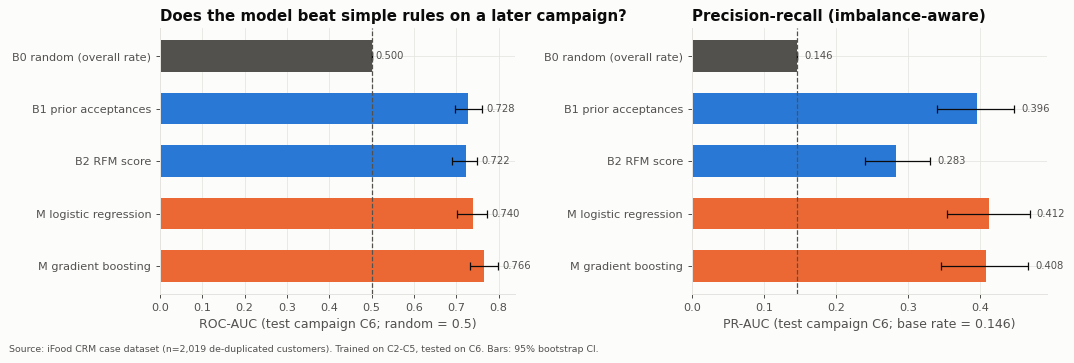

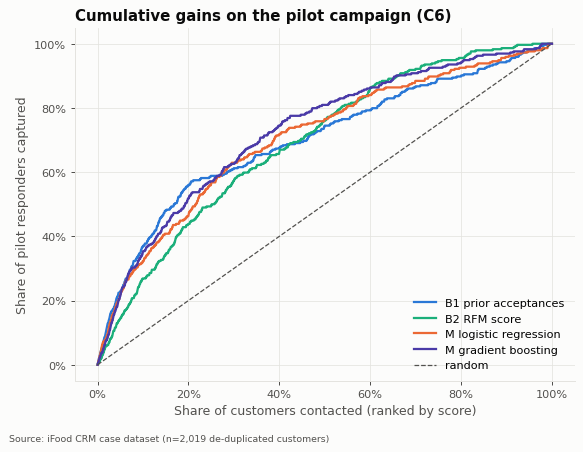

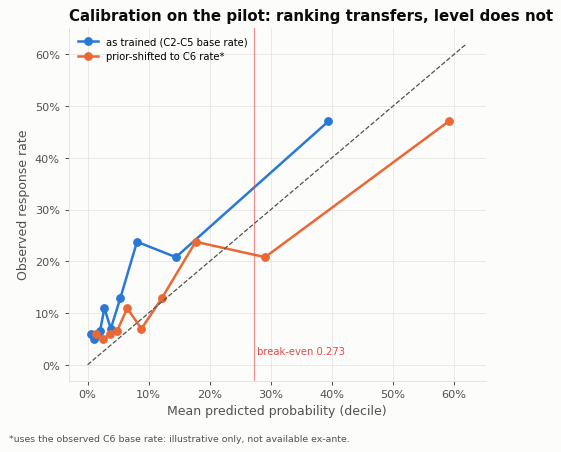

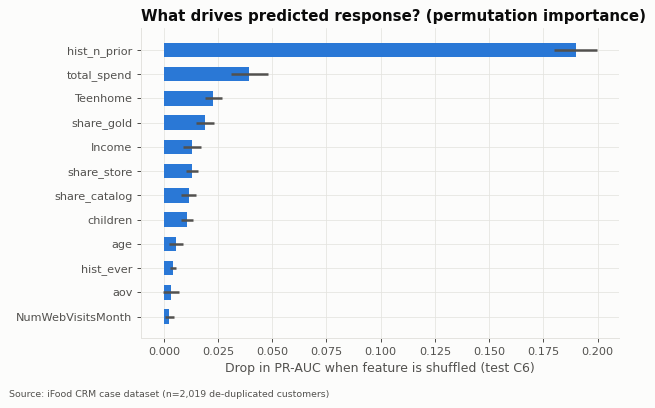

,model,params,C,loco_pr_auc,lr,depth,min_leaf
0,logistic_regression,C=0.01,0.01,0.1971,NaN,NaN,NaN
1,logistic_regression,C=0.1,0.1,0.1808,NaN,NaN,NaN
2,logistic_regression,C=1.0,1,0.1767,NaN,NaN,NaN
3,logistic_regression,C=10.0,10,0.1761,NaN,NaN,NaN
4,gradient_boosting,"lr=0.03,depth=2,min_leaf=40",NaN,0.1889,0.03,2,40
5,gradient_boosting,"lr=0.05,depth=3,min_leaf=40",NaN,0.1703,0.05,3,40
6,gradient_boosting,"lr=0.05,depth=3,min_leaf=100",NaN,0.1963,0.05,3,100
7,gradient_boosting,"lr=0.1,depth=2,min_leaf=100",NaN,0.1958,0.1,2,100


In [2]:
ctx = P.prepare('stage_model')
ctx = P.stage_model(ctx)
res = ctx['model']
print('train rows', res['train_rows'], 'test rows', res['test_rows'], '| primary:', res['primary_model'])
res['tuning']

In [3]:
ctx['model']['comparison'].drop(columns=['roc_auc_ci','pr_auc_ci'])

,approach,roc_auc,pr_auc,lift@10%,recall@10%,lift@20%,recall@20%,lift@30%,recall@30%
0,B0_random_(overall_rate),0.5,0.1456,0.8499,0.08503,1.037,0.2075,1.009,0.3027
1,B1_prior_acceptances,0.7276,0.3962,3.706,0.3707,2.788,0.5578,2.04,0.6122
2,B2_RFM_score,0.7224,0.2829,2.686,0.2687,2.193,0.4388,1.915,0.5748
3,M_logistic_regression,0.7401,0.412,3.23,0.3231,2.329,0.466,2.096,0.6293
4,M_gradient_boosting,0.7659,0.408,3.536,0.3537,2.584,0.517,2.085,0.6259


In [4]:
import pandas as pd
pd.read_csv(TAB/'model_paired_bootstrap_differences.csv')

,comparison,metric,mean_diff,ci_low,ci_high
0,diff_vs_B1,roc_auc_diff,0.01219,-0.01209,0.03545
1,diff_vs_B1,pr_auc_diff,0.01664,-0.01299,0.04304
2,diff_vs_B2,roc_auc_diff,0.01732,-0.0131,0.05023
3,diff_vs_B2,pr_auc_diff,0.1292,0.07589,0.1827
4,diff_gb_vs_lr,roc_auc_diff,0.02578,0.01253,0.04053
5,diff_gb_vs_lr,pr_auc_diff,-0.003372,-0.03531,0.0279


> **Finding:** On the later campaign the logistic model reaches ROC-AUC 0.74 / PR-AUC 0.41, versus 0.73 / 0.40 for the one-line rule 'number of earlier acceptances'. The PR-AUC gain is not significant (paired bootstrap CI −0.013 to +0.046). Gradient boosting has a slightly higher ROC-AUC but no better PR-AUC.
>
> **Business implication:** Machine learning adds little over campaign history for this decision; the transparent rule captures most of the value.
>
> **Recommended action:** Use the rule to define who is targeted; use the model only to order customers inside a tier and to explain drivers.
>
> **Evidence:** Temporal test on 2,019 customers; bootstrap CIs.
>
> **Assumption:** C6 behaves like a 'future' campaign relative to C2–C5.
>
> **Limitation:** Only 6 campaigns; campaigns differ strongly in who responds, so any model generalises imperfectly (held-out AUC 0.65–0.88 by campaign).

## Leakage checks

In [5]:
ctx['leak_auc']

,campaign,auc_recency,auc_spend,auc_web_visits,auc_income
0,C1,0.5294,0.8805,0.2765,0.8831
1,C2,0.5277,0.8148,0.4759,0.7684
2,C3,0.5386,0.5463,0.5764,0.4846
3,C4,0.4772,0.7613,0.4683,0.739
4,C5,0.5032,0.9221,0.2042,0.9361
5,C6 (pilot),0.6641,0.701,0.5019,0.636


In [6]:
pd.read_csv(TAB/'model_validation_designs.csv')

,design,roc_auc,pr_auc,lift@20%
0,"temporal (train C2-C5, test C6) - primary",0.7401,0.412,2.329
1,in-campaign 5-fold CV on C6 (optimistic reference),0.9146,0.6583,3.672


In [7]:
res['leakage_variants']

,feature_set,n_features,roc_auc,pr_auc,lift@10%,recall@10%,lift@20%,recall@20%,lift@30%,recall@30%
0,full,31,0.7401,0.412,3.23,0.3231,2.329,0.466,2.096,0.6293
1,no_recency,30,0.7417,0.4136,3.23,0.3231,2.363,0.4728,2.096,0.6293
2,history_demographics_only,16,0.7464,0.4619,3.468,0.3469,2.771,0.5544,2.232,0.6701


> **Finding:** Recency has no predictive power for C1–C5 (AUC 0.48–0.54) but clear power for the pilot (0.66). A same-campaign 5-fold CV on C6 reports AUC 0.91 — far above the honest temporal 0.74.
>
> **Business implication:** The snapshot was most likely taken *after* the pilot, so a pilot purchase reset Recency for responders. Any model validated inside C6 with Recency is inflated.
>
> **Recommended action:** Evaluate only with the temporal design; confirm results do not depend on Recency (they do not: PR-AUC 0.412 with vs 0.414 without).
>
> **Evidence:** Single-feature AUC by campaign; validation-design comparison; feature-set variants.
>
> **Assumption:** Snapshot timing inferred from the data pattern (not documented).
>
> **Limitation:** Spend over 'the last 2 years' may also include post-campaign purchases; the history+demographics-only model (no spend) performs as well (PR-AUC 0.46), so conclusions hold.

## Explainability and operating points

In [8]:
res['coefficients'].head(12)

,feature,std_coef,odds_ratio_per_sd
8,total_spend,0.3529,1.423
28,hist_n_prior,0.3462,1.414
21,category_entropy,-0.2714,0.7623
18,share_gold,0.2457,1.279
0,Income,0.2387,1.27
17,share_meat,-0.2305,0.7941
19,share_fish,-0.2281,0.7961
29,hist_last,-0.1799,0.8353
5,Teenhome,-0.1735,0.8407
16,share_wines,0.1638,1.178


In [9]:
res['perm_importance'].head(10)

,feature,pr_auc_drop_mean,pr_auc_drop_std
28,hist_n_prior,0.19,0.009922
8,total_spend,0.03934,0.008521
5,Teenhome,0.02288,0.003989
18,share_gold,0.01907,0.004212
0,Income,0.01312,0.004202
14,share_store,0.01306,0.00265
13,share_catalog,0.01151,0.00342
3,children,0.01057,0.002717
2,age,0.005528,0.003278
30,hist_ever,0.004322,0.001456


In [10]:
pd.read_csv(TAB/'model_operating_points.csv')

,operating_point,contacts,tp,fp,fn,tn,precision,recall,f1
0,top 10%,202,95,107,199,1618,0.4703,0.3231,0.3831
1,top 20%,404,137,267,157,1458,0.3391,0.466,0.3926
2,top 30%,606,185,421,109,1304,0.3053,0.6293,0.4111
3,raw p >= break-even 0.273,140,81,59,213,1666,0.5786,0.2755,0.3733


Calibration: trained on C2–C5 (base rate ≈ 5.7 %), the model under-predicts the pilot level (14.6 %) but ranks correctly;
the raw-probability break-even rule therefore contacts only 140 customers (precision 58 %). For forward scoring the
probabilities are prior-shifted to the pilot base rate — an explicit assumption, shown in the targeting engine.

In [11]:
res['calibration_raw']

,decile,mean_predicted,observed_rate,n
0,0,0.005791,0.05941,202
1,1,0.01037,0.0495,202
2,2,0.015,0.05941,202
3,3,0.02015,0.06436,202
4,4,0.02758,0.1089,202
5,5,0.03803,0.06965,201
6,6,0.05359,0.1287,202
7,7,0.08088,0.2376,202
8,8,0.1446,0.2079,202
9,9,0.394,0.4703,202
